#  Исследование результатов А/В-теста и поиск инсайтов

Автор проекта: Тишонкова Лада
Дата: 01.03.2026

SollmaFin — международное мобильное приложение для онлайн-торговли финансовыми активами. Пользователи могут инвестировать деньги в акции, валюту, криптовалюту, биржевые фонды (ETF) и другие активы. Целевая аудитория приложения — начинающие инвесторы. Получить доступ к финансовым рынкам можно со смартфона либо через веб-версию. 

Приложение ориентировано на рынок Латинской Америки с акцентом на четыре страны: Мексику, Бразилию, Колумбию и Аргентину — там быстро растёт интерес к финтеху и инвестициям, а экономики очень разные. 

Появилась гипотеза о недостаточной финансовой грамотности пользователей: они не понимают, как работать с активами разной степени риска. Клиенты покупают активы с высоким риском и теряют деньги, что снижает вовлечённость.
Команда продукта решила обновить онбординг пользователей и добавить в него детальную информацию о различиях финансовых активов и связанных с ними рисках. Однако появилось опасение, что углублённый онбординг отпугнёт клиентов от пополнения депозита и более рискованных вложений. 

Чтобы разобраться, команда решила провести A/B-эксперимент. 

### А/В-эксперимент

В эксперименте участвовали новые пользователи, которые зарегистрировались в приложении со 2 по 15 июня 2025 года. 
Пользователей случайным образом разделили на две равные группы: 
- Контрольная группа проходила стандартный онбординг без обязательного обучения.
- Тестовая группа проходила обновлённый онбординг с подробной информацией об активах и связанных с ними рисках. 

После разделения активность пользователей анализировали в течение недели.

Цель эксперимента — оценить, как обновлённый онбординг влияет на поведение пользователей и их дальнейшую инвестиционную активность.

При внедрении новой фичи команда продукта выдвинула такие гипотезы:
- Гипотеза роста: обучающий онбординг помогает пользователям лучше понимать принципы инвестирования, поэтому они будут чаще открывать второй депозит.
- Гипотеза риска: информация о возможных потерях и высоких рисках отпугнёт некоторых новичков, особенно самых осторожных, что снизит конверсию в первый депозит.
- Дополнительная гипотеза: после нового онбординга пользователи, которые выбрали высокорискованные активы, будут чаще, чем раньше, возвращаться и открывать второй депозит. При старом онбординге пользователи часто покупали активы с высоким риском без понимания последствий. Это приводило к потерям и оттоку после первого депозита. 

Чтобы увидеть полную картину, недостаточно следить за метриками конверсии. Команда выбрала для эксперимента такой набор метрик: 
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Ожидалось, что ключевая и барьерная метрики не упадут, а вспомогательные покажут значительный рост. 

### Задачи аналитика

Предстоит провести полный анализ результатов А/В-эксперимента. Но перед этим нужно погрузиться в продукт и изучить исторические данные.    


#### Анализ исторических данных

Чтобы понять, для чего была разработана новая фича, предстоит изучить исторические данные: 
- Поведение новых пользователей, в том числе динамику привлечения, сегментацию и ключевые этапы воронки действий.
- Метрики, связанные с внесением депозитов, в том числе средние суммы депозитов. 

####  Анализ данных А/В-теста

Изучение результатов эксперимента будет состоять из двух этапов: 
- Сравнение поведения пользователей в контрольной и тестовой группах, оценка статистической значимости изменений. 
- Исследование влияния нового онбординга на поведение платящих пользователей. В исследовании будем использовать бутстрап и сосредоточимся на нижних и верхних перцентилях распределения депозитов. 
- Такой подход позволит понять, как обновлённый онбординг повлиял на ключевые бизнес-метрики, найти точки роста и сформулировать рекомендации по улучшению пользовательского опыта и монетизации.


### Данные

Будем работать с двумя датасетами:  

1. Датасет `/datasets/pa_sollmafin_hist.csv` содержит исторические данные о ключевых действиях новых пользователей, привлечённых в период с 1 апреля по 1 июня 2025 года включительно. В датасете собраны действия пользователей до оформления второго депозита. 
2. Датасет `/datasets/pa_sollmafin_abt.csv` содержит данные А/В-эксперимента — все действия новых пользователей, которые зарегистрировались со 2 по 15 июня 2025 года включительно. Данные собраны в рамках проверки гипотезы о влиянии нового онбординга на поведение и активность пользователей. Пользователи уже распределены по группам А/В-эксперимента.

Общие поля датасетов:
- `user_id` — уникальный идентификатор пользователя;
- `country_code` — код страны пользователя в формате ISO (например, `BR` — Бразилия, `MX` — Мексика, `AR` — Аргентина, `CO` — Колумбия);
- `platform` — устройство, с которого пользователь взаимодействует с продуктом: mobile или web;
- `first_ts` — время первого появления пользователя в системе;
- `first_dt` — дата первого появления пользователя (без времени);
- `event_ts` — время события;
- `event_name` — название события;
- `amount` — сумма пополнения депозита;
- `asset` — тип приобретённого актива; 
- `risk_level` — уровень риска актива: low — низкий риск, medium — средний риск, high — высокий риск.

В датасете `/datasets/pa_sollmafin_abt.csv` содержатся два дополнительных поля:
- `ab_test` — название А/В-эксперимента;
- `group` — пользовательская группа А/В-эксперимента.


### План проекта
1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В эксперимента
4. Анализ изменений суммы депозитов на платящего пользователя
5. Выводы

---

## Часть 

###  Загрузка исторических данных и их предобработка

Загрузим данные из датасета `/datasets/pa_sollmafin_hist.csv` и получим основную информацию о них. Проведем предобработку. 

In [1]:
#Выгрузим необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
import numpy as np
import matplotlib.dates as mdates

In [2]:
#Загрузим данные 
df_hist = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_hist.csv', parse_dates=['first_ts', 'first_dt', 'event_ts'])
display(df_hist.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB


None

Датарфрейм содержит 10 столбцов( 3 типа datetime, 6 типа object, 1 типа float) и 238059 строк.

Пропуски есть в столбцах `amount`, `asset`, `risk_level`, что являетс янормальным, так как не все пользователи приложения пополняли депозит. Оставим эти пропуски без заполнения.

In [3]:
#Приведем данные с датой первого появления пользователя к типу date
df_hist['first_dt'] = df_hist['first_dt'].dt.date

In [4]:
display(df_hist['country_code'].unique())

array(['BR', 'AR', 'CO', 'MX'], dtype=object)

Присутствуют данные по пользователям из 4 стран: Бразилия, Аргентина, Колумбия, Мексика.

In [5]:
display(df_hist['platform'].unique())

array(['mobile', 'web'], dtype=object)

Пользователи делятся на два типа по платформам: mobile и web.

In [6]:
display(df_hist['event_name']. unique())

array(['install / open_web', 'introduction', 'registration', 'main_page',
       'onboarding_complete', 'first_deposit', 'asset_purchase',
       'second_deposit'], dtype=object)

Фиксируются следующие события пользователей:
- install / open_web установка/открытие сайта
- introduction введение
- registration регистрация
- main_page основная страница
- onboarding_complete онбординг пройден
- first_deposit  первый депозит
- asset_purchase покупка актива
- second_deposit второй депозит

In [7]:
display(df_hist['asset']. unique())

array([nan, 'stock', 'option', 'crypto'], dtype=object)

 3 типа активов: stock, option, crypto.

In [8]:
#Проверим данные на явные дубликаты
df_hist.duplicated().sum()

0

Явных дубликатов не обнаружено.

In [9]:
#Проверим данные на неявные дубликаты по user_id, event_ts, event_name
df_hist[['user_id', 'event_ts', 'event_name']].duplicated().sum()

0

Неявные дубликаты не обнаружены

In [10]:
#Посмотрим количество уникальных данных
uniq_user = df_hist['user_id'].nunique()
display(f'Количество уникальных пользователей: {uniq_user}')


min_date = df_hist['event_ts'].min()
max_date = df_hist['event_ts'].max()
display(f'Данные представлены от {min_date} до {max_date}')

'Количество уникальных пользователей: 41032'

'Данные представлены от 2025-04-01 00:06:34 до 2025-06-09 20:24:42'

Данные представлены с 1 апреля 2025 по 9 июня 2025 по 41032 уникальным пользователям.

In [11]:
#Проверим наличие отрицательных сумм депозитов
display(df_hist[df_hist['amount'] < 0 ].shape[0])

0

Отрицательных сумм по депозитам не обнаружено.

Загружены исторические данные с 1 апреля 2025 по 9 июня 2025г по 41032 уникальным пользователям. Дубликатов явных и неявных не обнаружено. Пропуски есть в столбцах с данными по депозитам и активам, что может быть - оставили  без изменений.

---

### Исследовательский анализ исторических данных

Проведем исследовательский анализ исторических данных. 

**Задача 2.1.** Анализ новых пользователей.
- Изучим динамику привлечения новых пользователей в приложение.

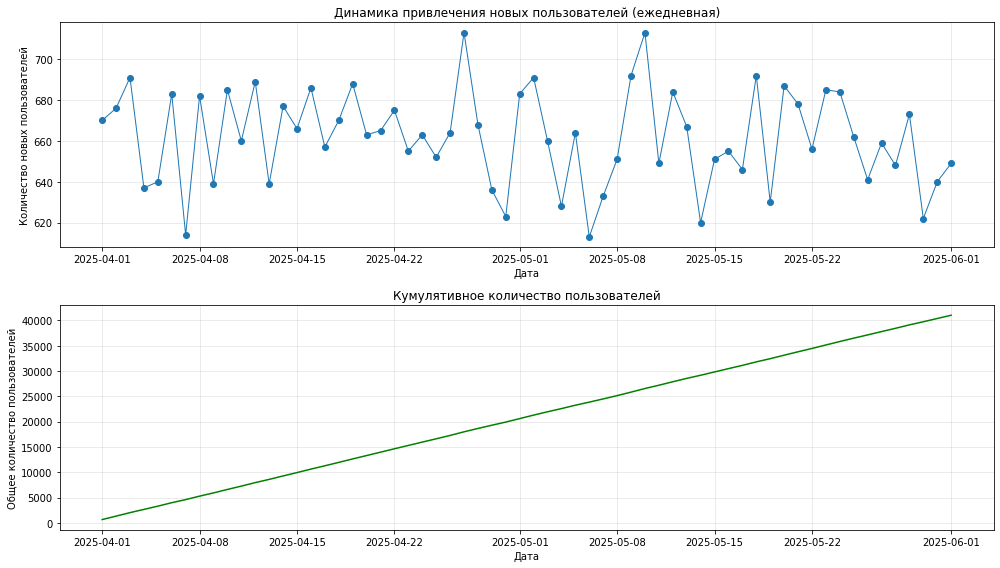

In [12]:
# Убедимся, что даты отсортированы
df_hist = df_hist.sort_values('first_ts')

# Считаем уникальных пользователей по дням регистрации
new_users_daily = df_hist.groupby('first_dt')['user_id'].nunique().reset_index()
new_users_daily.columns = ['date', 'new_users']

# Добавляем кумулятивную сумму
new_users_daily['cumulative_users'] = new_users_daily['new_users'].cumsum()

plt.figure(figsize=(14, 8))

# График ежедневных регистраций
plt.subplot(2, 1, 1)
plt.plot(new_users_daily['date'], new_users_daily['new_users'], marker='o', linewidth=1)
plt.title('Динамика привлечения новых пользователей (ежедневная)')
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')
plt.grid(True, alpha=0.3)

# Кумулятивный график
plt.subplot(2, 1, 2)
plt.plot(new_users_daily['date'], new_users_daily['cumulative_users'], color='green')
plt.title('Кумулятивное количество пользователей')
plt.xlabel('Дата')
plt.ylabel('Общее количество пользователей')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 Ежедневная динамика привлечения новых пользователей в приложение стабильна - от 600 до 700 пользователей в день, явных выбросов не наблюдается. Кривая кумулятивной суммы ровная имеет монотонный рост, что говорит о стабильности привлечения новых пользователей в приложение в исследуемый период.

**Задача 2.2.** Анализ воронок событий.
- Построим классическую и пошаговую воронки;
- Охарактеризуем пользовательский путь в приложении и определим узкие места воронки. 


In [13]:
# Задаем порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page',
       'onboarding_complete', 'first_deposit', 'asset_purchase',
       'second_deposit']
# Фильтруем датасет по заданным условиям - анализ данных в течени недели от начала пользования
df_hist['event_date'] = pd.to_datetime(df_hist['event_ts']).dt.date
df_hist_filtered = df_hist[df_hist['event_date'] <= (df_hist['first_dt'] + pd.Timedelta(days=7))]
# Фильтруем датасет оставляя только нужные шаги воронки
funnel_df_steps = df_hist_filtered[df_hist_filtered['event_name'].isin(funnel_steps)]
# Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_df_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_counts.values
})
# Добавляем конверсии
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)
display(funnel_df.head(10))

,step,users,conversion_from_first_%,conversion_from_previous_%
0,install / open_web,41032,100.0,NaN
1,introduction,41032,100.0,100.0
2,registration,38133,92.9,92.9
3,main_page,35040,85.4,91.9
4,onboarding_complete,34337,83.7,98.0
5,first_deposit,27685,67.5,80.6
6,asset_purchase,15392,37.5,55.6
7,second_deposit,5322,13.0,34.6


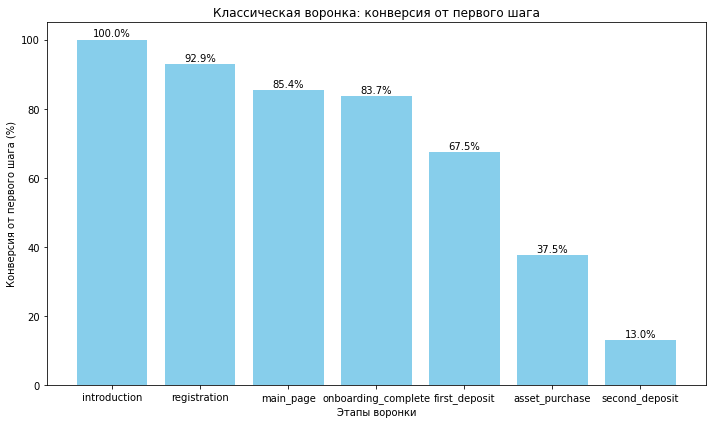

In [14]:
# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(10, 6))

bars = plt.bar(funnel_df['step'][1:], funnel_df['conversion_from_first_%'][1:], color='skyblue')

plt.title('Классическая воронка: конверсия от первого шага')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')

# Добавляем подписи значений над столбцами
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  
        height + 0.3,                          
        f'{funnel_df["conversion_from_first_%"][1:].iloc[i]:.1f}%',  
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.tight_layout()  
plt.show()

По визуализации классической воронки видно, что максимальное количество пользователей теряется на этапе покупки актива 30% и 24,5% не доходит до второго депозита, также 16,2% теряется на этапе первого депозита(т.е. после прохождения онбординга).

В целом до второго депозита доходит 13% пользователей, запустивших приложение. До регистрациии доходит 92,9%, переходит на основную страницу 85,4%, просматривает онбординг 83,7% пользователей, вносят первый депозит 67,5%, покупают актив 37,5% и делают второй депозит 13% пользователей.

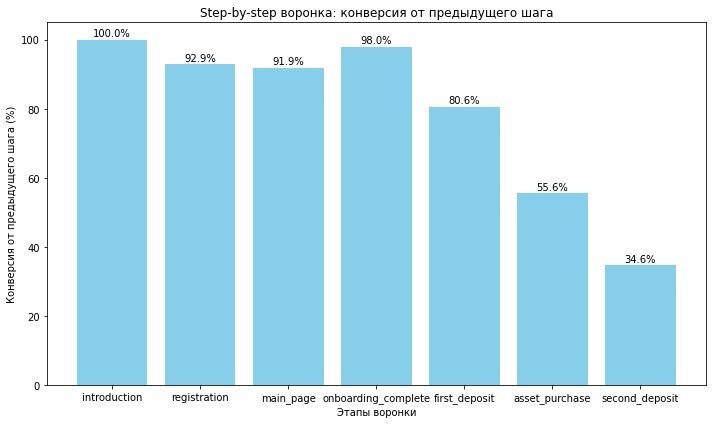

In [15]:
# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(10, 6))

bars = plt.bar(funnel_df['step'][1:], funnel_df['conversion_from_previous_%'][1:], color='skyblue')

plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
# Добавляем подписи значений над столбцами
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # по центру столбца
        height + 0.3,                           # чуть выше верха столбца
        f'{funnel_df["conversion_from_previous_%"][1:].iloc[i]:.1f}%',  # значение с 1 знаком после запятой + %
        ha='center', va='bottom', fontsize=10, color='black'
    )

plt.tight_layout()  
plt.show()

По step-by-step воронке видим также, что максимально уходят пользователи на этапе второго депозита 65,4% (после покупки актива), также 44,4% пользователей не доходят до покупки актива.

До регистрации доходит 92,9%, из них 91,9% переходят на основную страницу, затем 98% пользователей просматривает онбординг, первый депозит размещает 80,6% пользователей, актив покупают 55,6% и только 34,6% вносят второй депозит.

Таким образом, самым узким местом воронки является размещение второго депозита.

**Задача 2.3.** Влияние уровня риска актива на открытие второго депозита.
- Изучим, как уровень риска первого актива влияет на конверсию во второй депозит.  

In [16]:
# Фильтруем события покупки актива
# В расчетах используем фильтрованные по датам наблюдения данные
asset_purchases = df_hist_filtered[df_hist_filtered['event_name'] == 'asset_purchase']


# Берём первую покупку актива для каждого пользователя
first_asset = asset_purchases.sort_values('event_ts').groupby('user_id').first().reset_index()


# Оставляем только нужные колонки
first_asset = first_asset[['user_id', 'asset', 'risk_level']]

display(first_asset.head(10))

,user_id,asset,risk_level
0,000230df-cb80-4a99-9eb4-6e7b559cbd0a,stock,medium
1,00031d01-a2cc-4e28-be64-84c652318cf9,option,high
2,00044258-420d-40a2-8cfe-039c6c9deffd,option,medium
3,000734bf-9751-4dcc-b471-5528605ed91e,crypto,medium
4,00099973-e483-4b9c-963f-5dfd14c5b1a2,crypto,high
5,000e5bc1-cc48-46b7-bb6b-2f9f227d15ba,option,high
6,0011be83-c481-4f81-bc3b-87e91d93eb1e,option,high
7,00175a09-34fe-421a-a7bd-0e6d4739af71,stock,medium
8,0018822f-bb48-445d-a8ce-0d4e75205f0d,crypto,medium
9,001f4a9d-c5e1-4217-8913-c5b614b28e0c,option,high


In [17]:
# Определим пользователей, которые имеют второй депозит
second_deposit_users = df_hist_filtered[df_hist_filtered['event_name'] == 'second_deposit']['user_id'].unique()
#Добавим признак «второй депозит» к таблице first_asset
first_asset['have_second_deposit'] = first_asset['user_id'].isin(second_deposit_users).astype(int)
display(first_asset.head(10))

,user_id,asset,risk_level,have_second_deposit
0,000230df-cb80-4a99-9eb4-6e7b559cbd0a,stock,medium,0
1,00031d01-a2cc-4e28-be64-84c652318cf9,option,high,1
2,00044258-420d-40a2-8cfe-039c6c9deffd,option,medium,0
3,000734bf-9751-4dcc-b471-5528605ed91e,crypto,medium,0
4,00099973-e483-4b9c-963f-5dfd14c5b1a2,crypto,high,1
5,000e5bc1-cc48-46b7-bb6b-2f9f227d15ba,option,high,0
6,0011be83-c481-4f81-bc3b-87e91d93eb1e,option,high,0
7,00175a09-34fe-421a-a7bd-0e6d4739af71,stock,medium,1
8,0018822f-bb48-445d-a8ce-0d4e75205f0d,crypto,medium,0
9,001f4a9d-c5e1-4217-8913-c5b614b28e0c,option,high,0


In [18]:
# Рассчитаем конверсию по второй депозит пользователей, имеющих первый депозит
conversion_by_risk = first_asset.groupby('risk_level').agg(
    total_users=('user_id', 'count'),
    second_deposit_users=('have_second_deposit', 'sum')
).reset_index()

conversion_by_risk['conversion_rate'] = (conversion_by_risk['second_deposit_users'] /conversion_by_risk['total_users']) * 100

display(conversion_by_risk)

,risk_level,total_users,second_deposit_users,conversion_rate
0,high,7740,2009,25.956072
1,low,2327,1067,45.853030
2,medium,5325,2246,42.178404


Максимальная конверсия во второй депозит 45,9% у пользователей с низким риском актива, у пользователей со средним риском актива конверсия во второй депозит 42%, и минмальная конверсия во второй депозит 26% у пользователей с высоким степенем риска актива.

Таким образом, чем ниже риск первого депозита, тем выше конверсия во второй депозит. Это может быть связано с тем, что пользователи, выбирающие менее рискованные активы, чувствуют себя увереннее и с большей вероятностью продолжают инвестировать. А может быть, более рискованные активы требуют большей осознанности - без необходимости повторных покупок.

**Задача 2.4.** Анализ ключевой метрики на исторических данных.
- На исторических данных рассчитаем значение ключевой метрики — средней суммы всех депозитов на одного пользователя. Учитываем всех пользователей, которые взаимодействовали с сервисом. Это позволит зафиксировать базовый уровень монетизации.
- Визуализируем данные, где необходимо.

In [19]:
# Рассчитаем общее количество пользователей
total_users = df_hist_filtered['user_id'].nunique()

# Суммируем все депозиты на пользователя
user_deposits = df_hist_filtered.groupby('user_id')['amount'].sum().reset_index()
user_deposits.columns = ['user_id', 'total_deposits']


#Рассчитаем среднюю сумму всех депозитов на одного пользователя
avg_deposits_user = user_deposits['total_deposits'].sum()/ total_users

display(avg_deposits_user)

91.29169916162995

Базовый уровень монетизации 91,29.

In [20]:
# Описательная статистика
print("\nОписательная статистика по суммам депозитов на пользователя:")
print(user_deposits['total_deposits'].describe())

# Медиана (менее чувствительна к выбросам)
median_deposits = user_deposits['total_deposits'].median()
print(f"\nМедиана депозитов на пользователя с депозитами: {median_deposits:.2f}")

# Доля пользователей с депозитами
paying_users_ratio = len(df_hist[df_hist['event_name']=='first_deposit']) / total_users * 100
print(f"Доля пользователей с хотя бы одним депозитом: {paying_users_ratio:.2f}%")


Описательная статистика по суммам депозитов на пользователя:
count    41032.000000
mean        91.291699
std         80.070055
min          0.000000
25%          0.000000
50%         96.000000
75%        133.000000
max        656.000000
Name: total_deposits, dtype: float64

Медиана депозитов на пользователя с депозитами: 96.00
Доля пользователей с хотя бы одним депозитом: 67.47%


Среднее (91,29) близко к медиане (96,00), что говорит об отсутствии сильных выбросов в данных. Распределение относительно симметрично, без экстремального влияния отдельных крупных депозитов.

Стандартное отклонение (80) почти равно среднему (91,29), что указывает на высокую неоднородность сумм депозитов. Максимальная сумма депозита 656.

Платящих пользователей(имеющих хотя бы первый депозит) равна 67,5%.

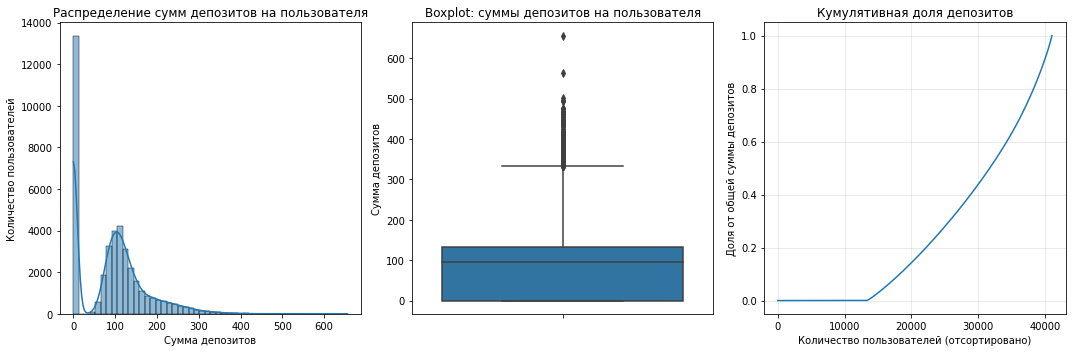

In [21]:
plt.figure(figsize=(15, 5))

# График 1: Гистограмма сумм депозитов (с ограничением для читаемости)
plt.subplot(1, 3, 1)
sns.histplot(user_deposits['total_deposits'], bins=50, kde=True)
plt.title('Распределение сумм депозитов на пользователя')
plt.xlabel('Сумма депозитов')
plt.ylabel('Количество пользователей')

# График 2: Boxplot для выявления выбросов
plt.subplot(1, 3, 2)
sns.boxplot(y=user_deposits['total_deposits'])
plt.title('Boxplot: суммы депозитов на пользователя')
plt.ylabel('Сумма депозитов')

# График 3: Кумулятивное распределение
plt.subplot(1, 3, 3)
sorted_deposits = user_deposits['total_deposits'].sort_values().cumsum()
plt.plot(range(len(sorted_deposits)), sorted_deposits / sorted_deposits.max())
plt.title('Кумулятивная доля депозитов')
plt.xlabel('Количество пользователей (отсортировано)')
plt.ylabel('Доля от общей суммы депозитов')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Видим пик на отметке 0 - 32,5% пользователей не имеют депозит, по имеющим депозит распределение нормальное. Вершина распределения приходится на 100-130.

Такое распределение - типичное явление для финансовых данных пользователей. Большая часть не делает вложений, поэтому суммы равны нулю, а среди инвесторов встречаются те, кто вкладывает редко, но очень крупные суммы. Из-за этого данные получаются сильно скошенными.

---

## Часть 

### Исследование результатов А/В эксперимента
Загрузим данные с результатами эксперимента (датасет `/datasets/pa_sollmafin_abt.csv `). Проверим корректность данных и проведем предобработку. 
Затем проведем анализ результатов А/В-эксперимента.


In [22]:
#Загрузим данные 
df_abt = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_abt.csv', parse_dates=['first_ts', 'first_dt', 'event_ts'])
display(df_abt.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB


None

In [23]:
#Приведем данные с датой первого появления пользователя к типу date
df_abt['first_dt'] = df_abt['first_dt'].dt.date

In [24]:
#Проверим на дубликаты
df_abt.duplicated().sum()

0

Дубликаты не обнаружены.

In [25]:
display(df_abt['ab_test'].unique())

array(['onboarding_test'], dtype=object)

Данные содержат только один тест - onboarding_test.

In [26]:
display(df_abt['group'].unique())

array(['test', 'control'], dtype=object)

Пользователи поделены на 2 группы - test и control.

In [27]:
#Посмотрим количество уникальных данных
uniq_user = df_abt['user_id'].nunique()
display(f'Количество уникальных пользователей: {uniq_user}')


min_date = df_abt['event_ts'].min()
max_date = df_abt['event_ts'].max()
display(f'Данные представлены от {min_date} до {max_date}')

min_date_reg = df_abt['first_dt'].min()
max_date_reg = df_abt['first_dt'].max()
display(f'Данные представлены по пользователям, зарегистрированным от {min_date_reg} до {max_date_reg}')

'Количество уникальных пользователей: 9415'

'Данные представлены от 2025-06-02 00:27:50 до 2025-06-22 13:37:05'

'Данные представлены по пользователям, зарегистрированным от 2025-06-02 до 2025-06-15'

Датафрейм содержит данные по 9415 уникальным пользователем, содержит информацию по действиям пользователей со 2 июня 2025 по 22 июня 2025 г, пришедшим с 2 по 15 июня 2025.

**Задача 3.1.** Анализ аудитории эксперимента. 
- Проверим корректность распределения новых пользователей по группам А/В-эксперимента. 
- Построим графики 

In [28]:
# Считаем кол-во уникальных групп на user_id
users = df_abt.groupby('user_id')['group'].nunique().reset_index()
# Фильтруем клиентов у которых больше 1 группы
users = users[users['group'] >1]

# Получение списка ID проблемных пользователей
user_ids = users['user_id'].unique()

# Фильтрация: оставляем только пользователей, которые находятся ровно в одной группе
df_abt_correct = df_abt[~df_abt['user_id'].isin(user_ids)]

# Подсчёт количества уникальных пользователей в очищенном датасете
num_users_correct = df_abt_correct['user_id'].nunique()

# Вывод результата
print(f'Количество пользователей после очистки: {num_users_correct}')

Количество пользователей после очистки: 9415


In [29]:
print(f'Начало регистрации {df_abt["first_ts"].min()}')
print(f'Конец регистрации {df_abt["first_ts"].max()}')

Начало регистрации 2025-06-02 00:27:50
Конец регистрации 2025-06-15 23:58:39


Пользователей, попавших одновременно в две группы не обнаружено.

,group,user_id,share
0,control,4847,0.514817
1,test,4568,0.485183


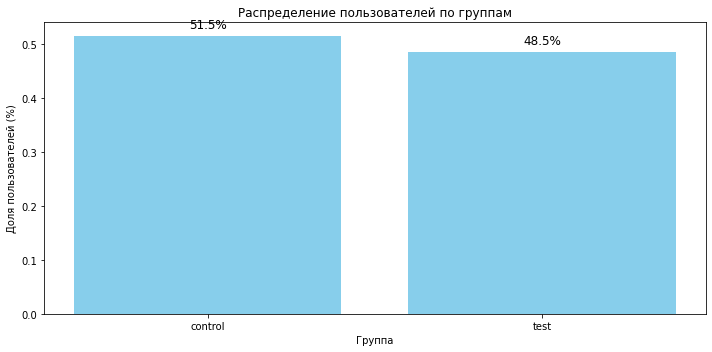

In [30]:
#Посчитаем долю пользователей по группам
share_user_abt = df_abt.groupby('group')['user_id'].nunique().reset_index()
total_user = df_abt['user_id'].nunique()
share_user_abt['share'] = share_user_abt['user_id'] / total_user
display(share_user_abt)


# Преобразуем доли в проценты для отображения
share_user_abt['share_percent'] = share_user_abt['share'] * 100

#Построим график
plt.figure(figsize=(10, 5))
bars = plt.bar(share_user_abt['group'], share_user_abt['share'], color='skyblue')

# Добавляем подписи значений над столбцами
for bar, percent in zip(bars, share_user_abt['share_percent']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  
        height + 0.01,                
        f'{percent:.1f}%',              
        ha='center',                   
        va='bottom',                       
        fontsize=12                                
    )
plt.title('Распределение пользователей по группам')
plt.ylabel('Доля пользователей (%)')
plt.xlabel('Группа')

plt.tight_layout() 
plt.show()

Распределение между группами равномерное:
- test 48,5%
- control 51,5%

,platform,group,count_user,total_user,share_user
0,mobile,control,3385,6631,51.048107
1,mobile,test,3246,6631,48.951893
2,web,control,1462,2784,52.514368
3,web,test,1322,2784,47.485632


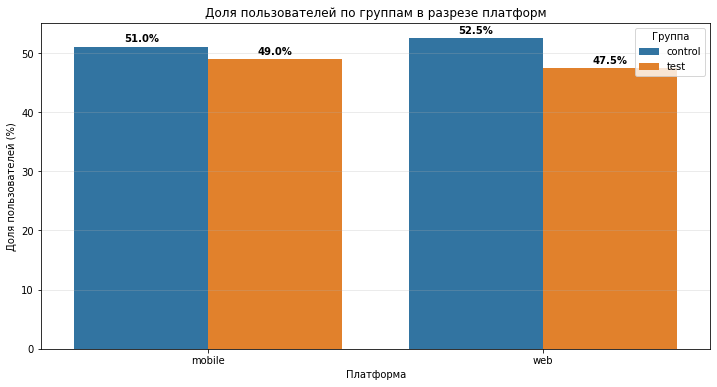

In [31]:
#Посмотрим распределение по платформам
user_platform_group = df_abt.groupby(['platform', 'group'])['user_id'].nunique().reset_index()
user_platform_group.columns = ['platform', 'group', 'count_user']
total_user_platform = df_abt.groupby('platform')['user_id'].nunique().reset_index()
total_user_platform.columns = ['platform', 'total_user']
platform_group = pd.merge(user_platform_group, total_user_platform, how='left', on='platform')
platform_group['share_user'] = 100 * platform_group['count_user'] / platform_group['total_user']

display(platform_group)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=platform_group, x='platform', y='share_user', hue='group')
# Добавляем подписи над каждым столбцом
for bar in ax.patches:
    # Получаем высоту столбца (значение доли)
    height = bar.get_height()
    if not np.isnan(height) and height > 0:  
        ax.text(
            bar.get_x() + bar.get_width() / 2,  
            height + 0.5, 
            f'{height:.1f}%',  
            ha='center',  
            va='bottom', 
            fontsize=10,
            fontweight='bold'
        )
plt.title('Доля пользователей по группам в разрезе платформ')
plt.ylabel('Доля пользователей (%)')
plt.xlabel('Платформа')
plt.legend(title='Группа')
plt.grid(axis='y', alpha=0.3)
plt.show()

Пользователи внутри групп по платформам распределены равномерно:
- web  52,5% и 47,5%
- mobile  51% b 49%

Таким образом пользователи по группам распределены равномерно.

**Задача 3.2.** Сравнение воронок событий.
- Сравним пользовательский путь новых пользователей в тестовой и контрольной группах.
- Построим классическую и последовательную воронки, выполним визуализацию

,step,control,test
0,introduction,100.0,100.0
1,registration,93.1,93.4
2,main_page,85.8,85.8
3,onboarding_complete,83.8,75.8
4,first_deposit,66.6,65.4
5,asset_purchase,36.6,43.3
6,second_deposit,13.5,21.3


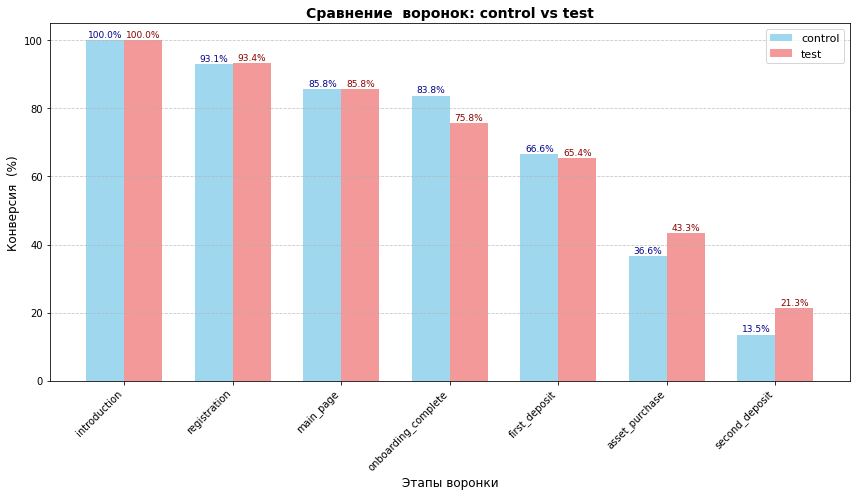

In [32]:
#Построим классическую воронку по группам
test_df = df_abt[df_abt['group']=='test']
control_df = df_abt[df_abt['group']=='control']
test_df_users = test_df['user_id'].nunique()
control_df_users = control_df['user_id'].nunique()
# Фильтруем датасет, оставляя только нужные шаги воронки для test
counts_test = test_df[test_df['event_name'].isin(funnel_steps)]
# Считаем количество клиентов на каждом шаге
counts_test_agg =counts_test.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
# Считаем конверсию для test и округляем значение до 1 знака после запятой
test_funnel = (counts_test_agg / test_df_users * 100).round(1)
# Повторяем шаги для control
counts_control = control_df[control_df['event_name'].isin(funnel_steps)]
counts_control_agg = counts_control.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
control_funnel =  (counts_control_agg / control_df_users * 100).round(1)

# Соберём через словарь данные в датафрейм и исключим первый шаг для каждого элемента
funnel_compare = pd.DataFrame({
   'step': funnel_steps[1:],
   'control': control_funnel[1:],
   'test': test_funnel[1:]
}).reset_index()

funnel_compare = funnel_compare[['step', 'control', 'test']]

display(funnel_compare.head(10))

plt.figure(figsize=(12, 7))

# Ширина столбцов и позиция на оси X
x = range(len(funnel_compare['step']))
width = 0.35

# Строим столбцы для mobile и desktop
plt.bar(x, funnel_compare['control'], width, label='control', color='skyblue', alpha=0.8)
plt.bar([p + width for p in x], funnel_compare['test'], width, label='test', color='lightcoral', alpha=0.8)

# Подписи осей и заголовок
plt.xlabel('Этапы воронки', fontsize=12)
plt.ylabel('Конверсия  (%)', fontsize=12)
plt.title('Сравнение  воронок: control vs test', fontsize=14, fontweight='bold')

# Метки по оси X (названия шагов)
plt.xticks([p + width / 2 for p in x], funnel_compare['step'], rotation=45, ha='right')

# Добавляем числовые значения над столбцами
for i, val in enumerate(funnel_compare['control']):
    plt.text(i, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='darkblue')

for i, val in enumerate(funnel_compare['test']):
    plt.text(i + width, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='darkred')

# Легенда и сетка
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

По этапам классической воронки наблюдаем ухудшение в тестовой группе на шагах onboarding_complete на 8% (тестовая 75,8 - контрольная 83,8) и небольшое на first_deposit 1,2% (тестовая 66,6% - контрольная 65,4%). Но при этом тестовая группа показывает значения лучше при покупке актива 43,3% против 36,6% и на этапе second_deposit 21,3 против 13,5%.

Таким образом, конверсия во второй депозит в тестовой группе на 7,8% больше, чем в контрольной.

 Мы явно видим улучшение на этапах покупки актива и внесения второго депозита, при этом низилась конверсия в успешный онбординг.

,step,control,test
0,introduction,100.0,100.0
1,registration,93.1,93.4
2,main_page,92.2,91.9
3,onboarding_complete,97.6,88.3
4,first_deposit,79.4,86.3
5,asset_purchase,54.9,66.2
6,second_deposit,36.9,49.3


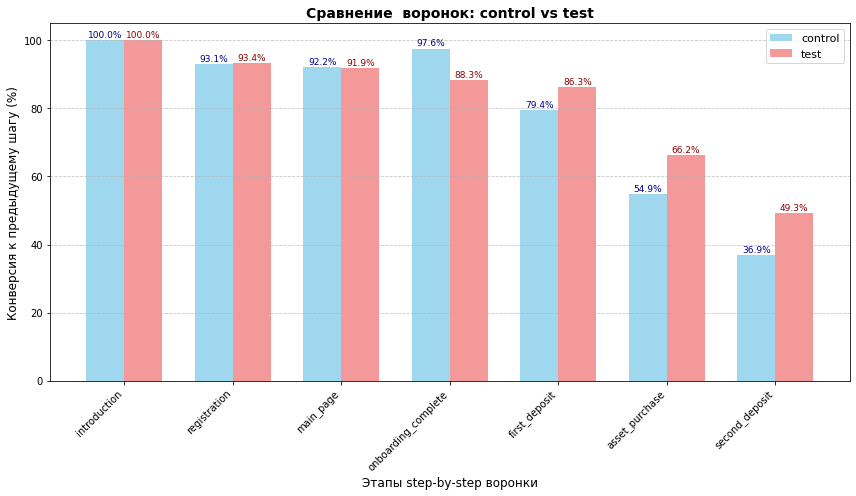

In [33]:
#Построим step-by-step воронку по группам
# Фильтруем датасет, оставляя только нужные шаги воронки для test
counts_test = test_df[test_df['event_name'].isin(funnel_steps)]
# Считаем количество клиентов на каждом шаге
counts_test_agg =counts_test.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
# Считаем конверсию для test и округляем значение до 1 знака после запятой
test_funnel = (counts_test_agg / counts_test_agg.shift(1) * 100).round(1)
# Повторяем шаги для control
counts_control = control_df[control_df['event_name'].isin(funnel_steps)]
counts_control_agg = counts_control.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
control_funnel =  (counts_control_agg / counts_control_agg.shift(1) * 100).round(1)

# Соберём через словарь данные в датафрейм и исключим первый шаг для каждого элемента
funnel_compare = pd.DataFrame({
   'step': funnel_steps[1:],
   'control': control_funnel[1:],
   'test': test_funnel[1:]
}).reset_index()

funnel_compare = funnel_compare[['step', 'control', 'test']]

display(funnel_compare.head(10))

plt.figure(figsize=(12, 7))

# Ширина столбцов и позиция на оси X
x = range(len(funnel_compare['step']))
width = 0.35

# Строим столбцы для mobile и desktop
plt.bar(x, funnel_compare['control'], width, label='control', color='skyblue', alpha=0.8)
plt.bar([p + width for p in x], funnel_compare['test'], width, label='test', color='lightcoral', alpha=0.8)

# Подписи осей и заголовок
plt.xlabel('Этапы step-by-step воронки', fontsize=12)
plt.ylabel('Конверсия к предыдущему шагу (%)', fontsize=12)
plt.title('Сравнение  воронок: control vs test', fontsize=14, fontweight='bold')

# Метки по оси X (названия шагов)
plt.xticks([p + width / 2 for p in x], funnel_compare['step'], rotation=45, ha='right')

# Добавляем числовые значения над столбцами
for i, val in enumerate(funnel_compare['control']):
    plt.text(i, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='darkblue')

for i, val in enumerate(funnel_compare['test']):
    plt.text(i + width, val + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='darkred')

# Легенда и сетка
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

По этапам step-by-step воронки ситуация схожая с классической: тестовая группа хуже на этапе onboarding_complete, но лучше на следующих:
- onboarding_complete тестовая группа 88,3 - контрольная 97,6
- first_deposit тестовая группа 86,3 - контрольная 79,4
- asset_purchase тестовая группа 66,2 - контрольная 54,9
- second_deposit тестовая группа 49,3 - контрольная 36,9

В результате анализа классической и step-by-step воронок пользователей в разрезе тестовой и контрольных групп можно сделать вывод, что после прохождения измененного онбординга пользователи стали лучше разбираться в активах и не бояться делать депозиты и покупать активы, также стали лучше разбираться в степени рисков активов и поэтому не уходят после покупки первых активов.

**Задача 3.3.** Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива.
- Проанализируем, как категория риска купленного актива влияет на вероятность открытия второго депозита в тестовой и контрольной группах. 
- Сравним результаты и оценим, есть ли статистически значимая разница между группами. 

In [34]:
# Фильтруем события покупки актива
asset_purchases = df_abt[df_abt['event_name'] == 'asset_purchase']


# Берём первую покупку актива для каждого пользователя
first_asset = asset_purchases.sort_values('event_ts').groupby('user_id').first().reset_index()

# Оставляем только нужные колонки
first_asset = first_asset[['user_id', 'group','asset', 'risk_level']]

display(first_asset.head(10))

,user_id,group,asset,risk_level
0,0009aedc-c389-4824-a05a-2354883b8c7e,test,stock,low
1,00191c86-8925-483c-9e4c-0859df770f3a,test,crypto,medium
2,00219f2d-50cc-4ec9-8f5b-6007b0565da0,control,crypto,medium
3,004951da-06b7-4d53-9df0-7ada3f9179d9,control,option,high
4,00a1052c-e742-4aa7-9e8c-f318943836ae,test,stock,low
5,00af20e6-8235-46bb-960f-f895f918f902,test,option,high
6,00bdd052-646f-4c53-9b07-5fe62e980001,test,crypto,high
7,00cfcd78-dc45-4c86-a833-f9bf3637faf5,test,stock,medium
8,00d4cba5-4c8b-4ed4-b278-fc890df25a9a,test,option,high
9,00daf17c-0c4f-4673-8f25-b055ea6d4270,test,stock,low


In [35]:
# Определим пользователей, которые имеют второй депозит
second_deposit_users = df_abt[df_abt['event_name'] == 'second_deposit']['user_id'].unique()
#Добавим признак «второй депозит» к таблице first_asset
first_asset['have_second_deposit'] = first_asset['user_id'].isin(second_deposit_users).astype(int)
display(first_asset.head(10))

,user_id,group,asset,risk_level,have_second_deposit
0,0009aedc-c389-4824-a05a-2354883b8c7e,test,stock,low,1
1,00191c86-8925-483c-9e4c-0859df770f3a,test,crypto,medium,0
2,00219f2d-50cc-4ec9-8f5b-6007b0565da0,control,crypto,medium,1
3,004951da-06b7-4d53-9df0-7ada3f9179d9,control,option,high,0
4,00a1052c-e742-4aa7-9e8c-f318943836ae,test,stock,low,0
5,00af20e6-8235-46bb-960f-f895f918f902,test,option,high,0
6,00bdd052-646f-4c53-9b07-5fe62e980001,test,crypto,high,1
7,00cfcd78-dc45-4c86-a833-f9bf3637faf5,test,stock,medium,1
8,00d4cba5-4c8b-4ed4-b278-fc890df25a9a,test,option,high,0
9,00daf17c-0c4f-4673-8f25-b055ea6d4270,test,stock,low,1


In [36]:
# Рассчитаем конверсию по второй депозит пользователей, имеющих первый депозит
conversion_by_risk = first_asset.groupby(['group','risk_level']).agg(
    total_users=('user_id', 'count'),
    second_deposit_users=('have_second_deposit', 'sum')
).reset_index()

conversion_by_risk['conversion_rate'] = (conversion_by_risk['second_deposit_users'] /conversion_by_risk['total_users']) * 100

display(conversion_by_risk)

,group,risk_level,total_users,second_deposit_users,conversion_rate
0,control,high,893,247,27.659574
1,control,low,285,142,49.824561
2,control,medium,595,265,44.537815
3,test,high,737,339,45.997286
4,test,low,496,285,57.459677
5,test,medium,744,350,47.043011


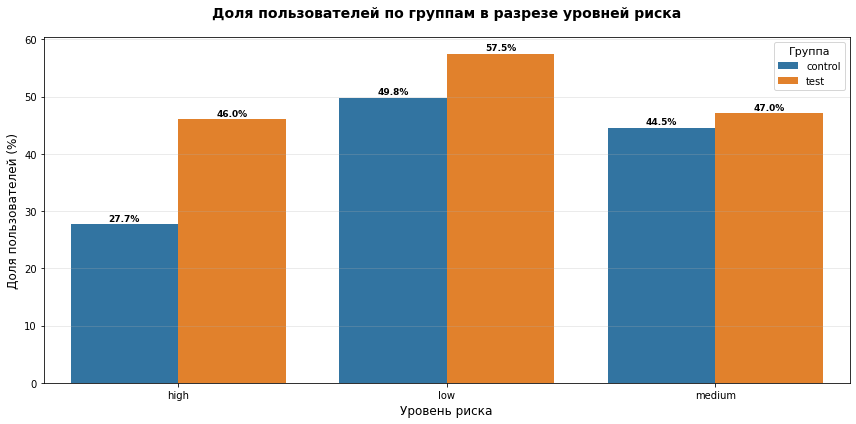

In [37]:
# Построим график
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=conversion_by_risk, x='risk_level', y='conversion_rate', hue='group')

plt.title('Доля пользователей по группам в разрезе уровней риска', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Доля пользователей (%)', fontsize=12)
plt.xlabel('Уровень риска', fontsize=12)
plt.legend(title='Группа', title_fontsize=11, fontsize=10)
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи к столбцам
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        # Проверяем, что значение не NaN и не 0
        if not pd.isna(height) and height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,  
                height + 0.3, 
                f'{height:.1f}%',  
                ha='center', 
                va='bottom', 
                fontsize=9,
                fontweight='bold',
                color='black'
            )

plt.tight_layout()
plt.show()

Таким образом, визуально видим, что конверсия во второй депозит в тестовой группе значительно выше, чем в контрольной для высокого  на 19,3% и низкого уровня риска актива на 7,7%, для среднего уровня риска конверсия во второй депозит отличается на 2,5%. Проверим является ли различие статистически значимым:

In [38]:
# Подготовим данные: считаем количество конверсий и общее число пользователей для каждой группы и уровня риска
summary_stats = conversion_by_risk.groupby(['risk_level', 'group']).agg({
    'conversion_rate': 'first',  
    'total_users': 'first'  
}).reset_index()

# Создадим словарь для хранения результатов
results = []

# Проводим попарное сравнение групп для каждого уровня риска
risk_levels = summary_stats['risk_level'].unique()

for risk in risk_levels:
    # Берём данные для текущего уровня риска
    risk_data = summary_stats[summary_stats['risk_level'] == risk]
    
    if len(risk_data) < 2:
        continue  # если группа одна, сравнение невозможно
    
    # Получаем данные для двух групп 
    control_data = risk_data[risk_data['group'] == 'control'].iloc[0]
    test_data = risk_data[risk_data['group'] == 'test'].iloc[0]
    
    # Рассчитываем количество конверсий 
    success_control = int(control_data['conversion_rate'] / 100 * control_data['total_users'])
    success_test = int(test_data['conversion_rate'] / 100 * test_data['total_users'])
    
    # Массивы успехов и наблюдений
    counts = [success_control, success_test]
    nobs = [control_data['total_users'], test_data['total_users']]
    
    # Проводим z‑тест
    z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')
    
    results.append({
        'risk_level': risk,
        'control_conversion': control_data['conversion_rate'],
        'test_conversion': test_data['conversion_rate'],
        'difference_%': round(test_data['conversion_rate'] - control_data['conversion_rate'], 2),
        'p_value': round(p_value, 4),
        'significant': p_value < 0.05
    })

# Преобразуем результаты в DataFrame
results_df = pd.DataFrame(results)
display(results_df)

,risk_level,control_conversion,test_conversion,difference_%,p_value,significant
0,high,27.659574,45.997286,18.34,0.0000,True
1,low,49.824561,57.459677,7.64,0.0391,True
2,medium,44.537815,47.043011,2.51,0.3607,False


Для высокого и низкого уровня риска конверсия во второй депозит различается статистически значимо между тестовой и контрольной группами. Для среднего уровная риска различие статистически не значимо.

**Задача 3.4.** Анализ метрик А/В-эксперимента. Проанализируем такие метрики:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Для каждой метрики выведем: 
- значения в контрольной и тестовой группах, 
- абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной.

После этого проверим статистическую значимость различий метрик между группами эксперимента. 

Для ключевой метрики также изучим:
- накопленную динамику изменения по дням эксперимента для каждой группы, 
- стабильность p-value во время эксперимента.


Проанализируем ключевую метрику - среднюю сумму всех депозитов на одного пользователя

In [39]:
#Рассчитаем метрику в контрольной группе
control_group = df_abt[df_abt['group']=='control']


control_user = control_group['user_id'].nunique()
control_revenue = control_group['amount'].sum()

avg_deposit_user_control = control_revenue / control_user
#Рассчитаем метрику в тестовой группе
test_group = df_abt[df_abt['group']=='test']

test_user = test_group['user_id'].nunique()
test_revenue = test_group['amount'].sum()

avg_deposit_user_test = test_revenue / test_user

#Рассчитаем абсолютную и относительную разницу
absolut_diff_conv = avg_deposit_user_test - avg_deposit_user_control
relative_diff_conv = ((avg_deposit_user_test - avg_deposit_user_control) / avg_deposit_user_control *100)

display(f"Средняя сумма всех депозитов на пользователя контрольная группа: {avg_deposit_user_control:+.2f}")
display(f"Средняя сумма всех депозитов на пользователя тестовая группа: {avg_deposit_user_test:+.2f}")
display(f'Абсолютное изменение: {absolut_diff_conv:+.2f}')
display(f'Относительное изменение: {relative_diff_conv:+.2f} %')

'Средняя сумма всех депозитов на пользователя контрольная группа: +90.24'

'Средняя сумма всех депозитов на пользователя тестовая группа: +92.46'

'Абсолютное изменение: +2.22'

'Относительное изменение: +2.46 %'

Средняя сумма всех депозитов на одного пользователя в тестовой группе 92,46 больше, чем в контрольной группе (90,24) на 2,22 или 2,46%.

Ключевая метрика не упала.

Проверим является ли увеличение ключевой метрики статистически значимым:

In [40]:
# Статистическая проверка значимости — t‑тест для независимых выборок

control_amounts = control_group.groupby('user_id')['amount'].sum()
test_amounts = test_group.groupby('user_id')['amount'].sum()

# Выполняем t‑тест Уэлча
t_stat, p_value = stats.ttest_ind(control_amounts,test_amounts,equal_var=False)
is_significant = p_value < 0.05

print(f"  Статистическая значимость (p‑value): {p_value:.4f}")
print(f"  Результат значим (p < 0.05): {'Да' if is_significant else 'Нет'}")

  Статистическая значимость (p‑value): 0.3383
  Результат значим (p < 0.05): Нет


Разница средней суммы всех депозитов на одного пользователя в тестовой и контрольной группе статистически не значима.

Рассчитаем накопленную динамику изменения по дням эксперимента для каждой группы:

(array([20240., 20244., 20248., 20252., 20256., 20260.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

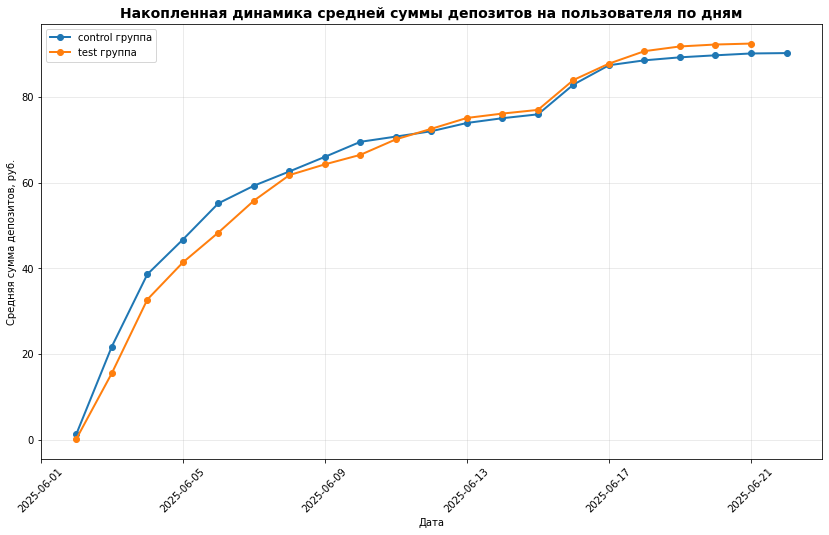

In [41]:
df_abt = df_abt.copy()
df_abt['event_date'] = pd.to_datetime(df_abt['event_ts']).dt.date

# Сортируем по дате для корректного расчёта нарастающего итога
df_sorted = df_abt.sort_values('event_date')

# Создаём DataFrame с ежедневными данными
daily_data = df_sorted.groupby(['event_date', 'group']).agg(
    daily_users=('user_id', 'nunique'),
    daily_revenue=('amount', 'sum')
).reset_index()

# Функция для расчёта кумулятивного количества уникальных пользователей
def calculate_cumulative_unique_users(group_data):
    # Получаем все уникальные даты в эксперименте
    all_dates = sorted(df_sorted['event_date'].unique())
    
    # Получаем группу (control/test)
    group_name = group_data['group'].iloc[0]
    
    cumulative_users = []
    seen_users = set()  # Множество уже встреченных пользователей
    
    for date in all_dates:
        # Фильтруем данные за текущий день для группы
        day_data = df_sorted[(df_sorted['event_date'] == date) & (df_sorted['group'] == group_name)]
        # Добавляем новых пользователей за день в общее множество
        new_users_today = set(day_data['user_id'].dropna())
        seen_users.update(new_users_today)
        # Записываем накопленное количество уникальных пользователей
        cumulative_users.append(len(seen_users))
    return pd.Series(cumulative_users, index=all_dates)

# Применяем функцию для каждой группы
groups = df_sorted['group'].unique()
cumulative_user_counts = {}

for group in groups:
    cumulative_user_counts[group] = calculate_cumulative_unique_users(daily_data[daily_data['group'] == group])

# Объединяем кумулятивные данные с ежедневными
final_data = []
for group in groups:
    group_daily = daily_data[daily_data['group'] == group].copy()
    # Добавляем кумулятивное количество пользователей
    group_daily['cumulative_unique_users'] = group_daily['event_date'].map(cumulative_user_counts[group])
    # Кумулятивная выручка
    group_daily['cumulative_revenue'] = group_daily['daily_revenue'].cumsum()
    # Ключевая метрика: средняя сумма депозитов на уникального пользователя с начала эксперимента
    group_daily['cumulative_key_metric'] = (group_daily['cumulative_revenue'] / group_daily['cumulative_unique_users']).round(2)
    final_data.append(group_daily)

# Объединяем данные по всем группам
deposit_date = pd.concat(final_data, ignore_index=True)
deposit_date = deposit_date.sort_values(['group', 'event_date'])

plt.figure(figsize=(14, 8))

# График 1: Кумулятивная метрика
for group in groups:
    group_data = deposit_date[deposit_date['group'] == group]
    plt.plot(
        group_data['event_date'],
        group_data['cumulative_key_metric'],
        label=f'{group} группа',
        marker='o',
        linewidth=2
    )
plt.title('Накопленная динамика средней суммы депозитов на пользователя по дням', fontsize=14, fontweight='bold')
plt.ylabel('Средняя сумма депозитов, руб.')
plt.xlabel('Дата')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

По визуализации накопленной динамики средней суммы депозитов на пользователя видно, что после 12 июня показатели тестовой группы становятся больше контрольной и показывает более быстрый рост.

Также стоит обратить снимание на "ступеньки" - то, что они появились, может намекать нам на то, что пользователи начали делать вторые, крупные депозиты. А ступенька после 16 числа - именно в этот день завершился набор новых пользователей, и далее в выборке остались только активные пользователи

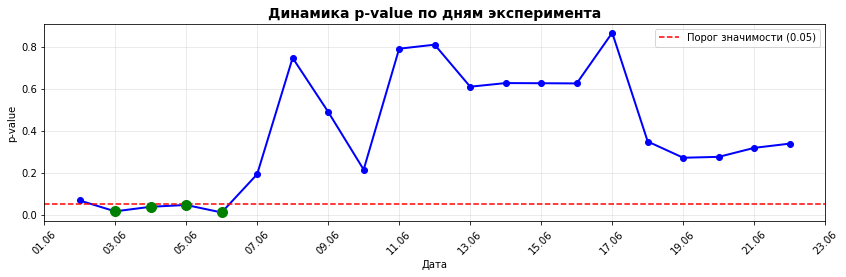

In [42]:
# Рассчитываем кумулятивное p‑value по дням для A/B‑теста.
def calculate_cumulative_p_value(df, date_col='event_date', group_col='group', value_col='amount'):
    """
    Рассчитывает кумулятивное p‑value по дням для A/B‑теста.
    """
    # Получаем уникальные даты в хронологическом порядке
    unique_dates = sorted(df[date_col].unique())
    results = []

    for i, current_date in enumerate(unique_dates):
        # Берём данные с начала эксперимента до текущей даты
        cumulative_data = df[df[date_col] <= current_date]

        # Разделяем на группы
        control_data = cumulative_data[cumulative_data[group_col] == 'control'].groupby('user_id')[value_col].sum()
        test_data = cumulative_data[cumulative_data[group_col] == 'test'].groupby('user_id')[value_col].sum()

        # Выполняем t‑тест
        t_stat, p_value = stats.ttest_ind(control_data, test_data, equal_var=False)
        is_significant = p_value < 0.05
       
        results.append({
            'date': current_date,
            'cumulative_days': i + 1,
            'control_users': cumulative_data[cumulative_data[group_col] == 'control']['user_id'].nunique(),
            'test_users': cumulative_data[cumulative_data[group_col] == 'test']['user_id'].nunique(),
            'p_value': p_value,
            'is_significant': is_significant
        })

    return pd.DataFrame(results)

# Рассчитываем кумулятивное p‑value
p_value_stability = calculate_cumulative_p_value(
    df_abt,
    date_col='event_date',
    group_col='group',
    value_col='amount'
)

plt.figure(figsize=(14, 8))

# Динамика p‑value
plt.subplot(2, 1, 1)
plt.plot(
    p_value_stability['date'],
    p_value_stability['p_value'],
    marker='o',
    linewidth=2,
    color='blue'
)
# Горизонтальная линия порога значимости (0.05)
plt.axhline(y=0.05, color='red', linestyle='--', label='Порог значимости (0.05)')
plt.title('Динамика p‑value по дням эксперимента', fontsize=14, fontweight='bold')
plt.ylabel('p‑value')
plt.xlabel('Дата')
plt.legend()
plt.grid(True, alpha=0.3)

# Форматирование оси X для дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

# Добавляем отметки дней, когда p‑value стало значимым
significant_days = p_value_stability[p_value_stability['is_significant']]
if not significant_days.empty:
    plt.scatter(
        significant_days['date'],
        significant_days['p_value'],
        color='green',
        s=100,
        zorder=5,
        label='Значимые дни'
    )

Динамика p-value по дням эксперимента стабильна до 7 июня  и не превышает 0,05, после 7 июня значение p-value существенно превышает порог значимости. Вероятно, на начальном этапе эффект был сильным, поэтому тест показал значимость в виду недостаточного количества данных. Затем по мере накопления данных распределение стало более «шумным», и эффект размылся.

Перейдем к расчету и анализу барьерной метрики - конверсия из регистрации в первый депозит

In [43]:
#Рассчитаем конверсию из регистрации в первый депозит в контрольной группе
control_group = df_abt[df_abt['group']=='control']


total_user_control = control_group[control_group['event_name']=='registration']['user_id'].nunique()
control_user_f_dep = control_group[control_group['event_name']=='first_deposit']
deposit_user_control = control_user_f_dep['user_id'].nunique()
conversion_control_deposit = (deposit_user_control / total_user_control * 100)

#Рассчитаем конверсию из регистрации в первый депозит в тестовой группе
test_group = df_abt[df_abt['group']=='test']

total_user_test = test_group[test_group['event_name']=='registration']['user_id'].nunique()
test_user_f_dep = test_group[test_group['event_name']=='first_deposit']
deposit_user_test = test_user_f_dep['user_id'].nunique()
conversion_test_deposit = (deposit_user_test/ total_user_test * 100)

#Рассчитаем абсолютную и относительную разницу
absolut_diff_conv = conversion_test_deposit - conversion_control_deposit
relative_diff_conv = ((conversion_test_deposit - conversion_control_deposit) / conversion_control_deposit *100)

display(f"Конверсия из регистрации в первый депозит контрольная группа: {conversion_control_deposit:+.2f}")
display(f"Конверсия из регистрации в первый депозит тестовая группа: {conversion_test_deposit:+.2f}")
display(f'Абсолютное изменение: {absolut_diff_conv:+.2f}')
display(f'Относительное изменение: {relative_diff_conv:+.2f} %')

'Конверсия из регистрации в первый депозит контрольная группа: +71.54'

'Конверсия из регистрации в первый депозит тестовая группа: +70.04'

'Абсолютное изменение: -1.51'

'Относительное изменение: -2.11 %'

Конверсия из регистрации в первый депозит в тестовой группе(70,04) ниже, чем в контрольной(71,54) на 1,51 или 2,11%. Барьерная метрика ухудшилась. Проверим на статистическую значимость:

In [44]:
# Статистическая проверка значимости (z‑тест для пропорций)
try:
    # Данные для теста: [число успехов, число успехов], [общее число, общее число]
    successes = [deposit_user_control, deposit_user_test]
    totals = [total_user_control, total_user_test]

    z_stat, p_value = proportions_ztest(successes, totals)
    is_significant = p_value < 0.05
except Exception as e:
    p_value = np.nan
    is_significant = False
    print(f"Ошибка при расчёте статистической значимости: {e}")
    
    
print(f"  Статистическая значимость (p‑value): {p_value:.4f}")
print(f"  Результат значим (p < 0.05): {'Да' if is_significant else 'Нет'}")

  Статистическая значимость (p‑value): 0.1205
  Результат значим (p < 0.05): Нет


Статистически разица конверсии из регистрации в первый депозит не значима, т.е. ухудшение метрики в тестовой группе не значительно.

Перейдем к расчету и анализу 1 вспомогательной метрики - конверсии из первого во второй депозит:

In [45]:
#Рассчитаем метрику в контрольной группе
control_group = df_abt[df_abt['group']=='control']


control_user_f_dep = control_group[control_group['event_name']=='first_deposit']['user_id'].nunique()
control_user_s_dep = control_group[control_group['event_name']=='second_deposit']['user_id'].nunique()

conversion_control_s_deposit = (control_user_s_dep / control_user_f_dep * 100)

#Рассчитаем метрику в тестовой группе
test_group = df_abt[df_abt['group']=='test']

test_user_f_dep = test_group[test_group['event_name']=='first_deposit']['user_id'].nunique()
test_user_s_dep = test_group[test_group['event_name']=='second_deposit']['user_id'].nunique()

conversion_test_s_deposit = (test_user_s_dep/ test_user_f_dep * 100)

#Рассчитаем абсолютную и относительную разницу
absolut_diff_conv = conversion_test_s_deposit - conversion_control_s_deposit
relative_diff_conv = ((conversion_test_s_deposit - conversion_control_s_deposit) / conversion_control_s_deposit *100)

display(f"Конверсия из первого во второй депозит контрольная группа: {conversion_control_s_deposit:+.2f}")
display(f"Конверсия из первого во второй депозит тестовая группа: {conversion_test_s_deposit:+.2f}")
display(f'Абсолютное изменение: {absolut_diff_conv:+.2f}')
display(f'Относительное изменение: {relative_diff_conv:+.2f} %')

'Конверсия из первого во второй депозит контрольная группа: +20.26'

'Конверсия из первого во второй депозит тестовая группа: +32.61'

'Абсолютное изменение: +12.35'

'Относительное изменение: +60.95 %'

Конверсия из первого во второй депозит в тестовой группе 32,61 больше конверсии в контрольной группе 20,26 на 12,35 или на 60,95%. Проверим статистическую значимость разницы:

In [46]:
# Статистическая проверка значимости (z‑тест для пропорций)
try:
    # Данные для теста: [число успехов, число успехов], [общее число, общее число]
    successes = [control_user_s_dep, test_user_s_dep]
    totals = [control_user_f_dep, test_user_f_dep]

    z_stat, p_value = proportions_ztest(successes, totals)
    is_significant = p_value < 0.05
except Exception as e:
    p_value = np.nan
    is_significant = False
    print(f"Ошибка при расчёте статистической значимости: {e}")
    
    
print(f"  Статистическая значимость (p‑value): {p_value:.4f}")
print(f"  Результат значим (p < 0.05): {'Да' if is_significant else 'Нет'}")

  Статистическая значимость (p‑value): 0.0000
  Результат значим (p < 0.05): Да


Разница конверсии из первого во второй депозит тестовой и контрольной группы статистически значима. Т.е. в тестовой группе конверсия во второй депозит значимо выше контрольной группы.

Перейдем к расчету и анализу 2 вспомогательной метрики - средней суммы всех депозитов на пользователя, который открыл хотя бы один депозит:

In [47]:
#Рассчитаем метрику в контрольной группе
control_group = df_abt[df_abt['group']=='control']


control_user_f_dep = control_group[control_group['event_name']=='first_deposit']['user_id'].nunique()
control_revenue = control_group['amount'].sum()

avg_deposit_user_control = control_revenue / control_user_f_dep

#Рассчитаем метрику в тестовой группе
test_group = df_abt[df_abt['group']=='test']

test_user_f_dep = test_group[test_group['event_name']=='first_deposit']['user_id'].nunique()
test_revenue = test_group['amount'].sum()

avg_deposit_user_test = test_revenue / test_user_f_dep

#Рассчитаем абсолютную и относительную разницу
absolut_diff_conv = avg_deposit_user_test - avg_deposit_user_control
relative_diff_conv = ((avg_deposit_user_test - avg_deposit_user_control) / avg_deposit_user_control *100)

display(f"Средняя сумма всех депозитов на пользователя контрольная группа: {avg_deposit_user_control:+.2f}")
display(f"Средняя сумма всех депозитов на пользователя тестовая группа: {avg_deposit_user_test:+.2f}")
display(f'Абсолютное изменение: {absolut_diff_conv:+.2f}')
display(f'Относительное изменение: {relative_diff_conv:+.2f} %')

'Средняя сумма всех депозитов на пользователя контрольная группа: +135.50'

'Средняя сумма всех депозитов на пользователя тестовая группа: +141.40'

'Абсолютное изменение: +5.90'

'Относительное изменение: +4.35 %'

 Средняя сумма всех депозитов на пользователя в тестовой группе 141,4 выше, чем в контрольной группе 135,50 на 5,9 или 4,35%. Проверим статистическую значимость:

In [48]:
# Статистическая проверка значимости — t‑тест для независимых выборок
# Берем только положительные депозиты
deposits = df_abt[df_abt['amount'] > 0]

# Считаем сумму всех депозитов на пользователя в разрезе групп
user_revenue = (
    deposits
    .groupby(['user_id', 'group'], as_index=False)
    .agg({'amount': 'sum'})
)

# Делим на группы
control_amounts = user_revenue[user_revenue['group'] == 'control']['amount']
test_amounts = user_revenue[user_revenue['group'] == 'test']['amount']

# ARPPU
arppu_control = control_amounts.mean()
arppu_test = test_amounts.mean()

print(f'ARPPU контроль: {arppu_control:.2f}')
print(f'ARPPU тест: {arppu_test:.2f}')

# t-тест Уэлча по тем же самым данным
t_stat, p_value = stats.ttest_ind(control_amounts, test_amounts, equal_var=False)

    
print(f"  Статистическая значимость (p‑value): {p_value:.4f}")
print(f"  Результат значим (p < 0.05): {'Да' if is_significant else 'Нет'}")

ARPPU контроль: 135.50
ARPPU тест: 141.40
  Статистическая значимость (p‑value): 0.0400
  Результат значим (p < 0.05): Да


Разница средней суммы всех депозитов пользователей, сделавших хоть один депозит, статистически значима. 

Т.е. средняя сумма всех депозитов пользователей, сделавших хотя бы один депозит, значима.

Вывод:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию) в тестовой группе 92,46 больше, чем в контрольной группе (90,24) на 2,22 или 2,46%. Статистически разница с контрольной группой не значима. Накопительно значение метрики в тестовой группе становится больше контрольной с 12 июня. Динамика p-value по дням эксперимента стабильна до 7 июня  и не превышает 0,05, после 7 июня значение p-value существенно превышает порог значимости. Вероятно, на начальном этапе эффект был сильным, поэтому тест показал значимость в виду недостаточного количества данных. Затем по мере накопления данных распределение стало более «шумным», и эффект размылся.
- Барьерная метрика — конверсия из регистрации в первый депозит в тестовой группе(70,04) ниже, чем в контрольной(71,54) на 1,51 или 2,11%. Барьерная метрика ухудшилась. Статистически разница конверсии из регистрации в первый депозит не значима
- Вспомогательная метрика 1 — конверсия из первого во второй депозит в тестовой группе 32,61 больше конверсии в контрольной группе 20,26 на 12,35 или на 60,95%. Разница конверсии из первого во второй депозит тестовой и контрольной группы статистически значима. Т.е. в тестовой группе конверсия во второй депозит значимо выше контрольной группы.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит в тестовой группе 141,4 выше, чем в контрольной группе 135,50 на 5,9 или 4,35%.  Разница средней суммы всех депозитов пользователей, сделавших хоть один депозит, статистически значима. 

Ожидание от внедрения нового онбординга было, что ключевая и барьерная метрики не упадут, а вспомогательные покажут значительный рост.

Т.к. ухудшение барьерной метрики статистически не значимо, можно сделать вывод, что ожидания от внедрения нового онбординга подтвердилось.

---

### 4. Анализ изменений суммы депозитов на платящего пользователя

Новая фича могла повлиять на поведение пользователей.
- Пользователи, которые раньше вносили небольшие суммы, могли стать более осторожными, сократить свои вложения или совсем перестать платить. Это отразится в снижении 25-го перцентиля суммы депозитов в тестовой группе.
- Пользователи, которые склонны к более крупным инвестициям, могли сильнее вовлечься в продукт и начать вносить больше средств. Это отразится в росте 75-го перцентиля.

Используя бутстрап, сравним разницы перцентилей (25, 50, 75) суммы всех депозитов на платящего пользователя в контрольной и тестовой группах:
- Построим доверительные интервалы для разницы между группами для каждого перцентиля.
- Визуализируем результат бутстрап-теста. 

Сравним разницы 75-перцентилей:

In [49]:
# Фиксируем сид для воспроизводимости
np.random.seed(341)
#Фильтруем платящих пользователей
pay_users = df_abt[df_abt['amount'] > 0]

control = pay_users[pay_users['group'] == 'control']
test = pay_users[pay_users['group'] == 'test']

control_group = control.groupby('user_id')['amount'].sum()
test_group = test.groupby('user_id')['amount'].sum()


n_iterations = 10000
boot_diffs = []

# Бутстрап-разница 75-х перцентилей между тестовой и контрольной группами
for i in range(n_iterations):
    boot_control = np.random.choice(control_group, size=len(control_amounts), replace=True)
    boot_test = np.random.choice(test_group, size=len(test_amounts), replace=True)

    # Для расчёта 95 перцентиля используем .percentile() из библиотеки numpy 
    control_75p = np.percentile(boot_control, 75)
    test_75p = np.percentile(boot_test, 75)

    # Находим разницу между значениями тестовой и контрольной групп
    boot_diffs.append(test_75p - control_75p)

# Создаём массив разниц между 95-ми перцентилями тестовой и контрольной групп
boot_diffs = np.array(boot_diffs)

# Доверительный интервал разницы между 75-ми перцентилями (перцентильный метод)
diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Вывод доверительного интервала
print(f"75-й перцентиль контрольной группы: {np.percentile(control_group, 75):.2f}")
print(f"75-й перцентиль тестовой группы: {np.percentile(test_group, 75):.2f}")
print(f"95%-й доверительный интервал разности 75-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]")

75-й перцентиль контрольной группы: 159.00
75-й перцентиль тестовой группы: 179.50
95%-й доверительный интервал разности 75-х перцентилей [11.00, 30.00]


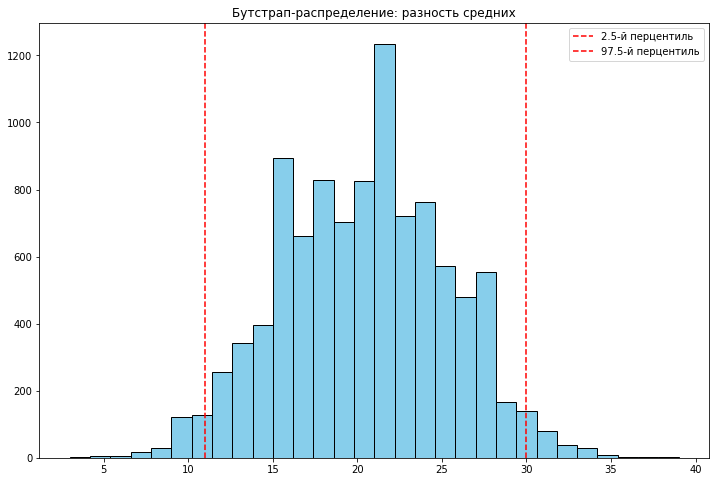

In [50]:
plt.figure(figsize=(12, 8))

# Визуализация
plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
plt.axvline(diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
plt.title("Бутстрап-распределение: разность средних")
plt.legend()
plt.show()

Наблюдаемое увеличение 75‑го перцентиля с 159 до 179,5 руб.  является статистически значимым (95 % ДИ: [11;30]). Крупные инвесторы (верхние 25 %) действительно стали вкладывать больше: их депозиты выросли в среднем на 20,50 (диапазон 11,00–30,00)

Сравним разницы 50-перцентилей:

50-й перцентиль контрольной группы: 118.00
50-й перцентиль тестовой группы: 94.00
95%-й доверительный интервал разности 50-х перцентилей [-27.00, -19.00]


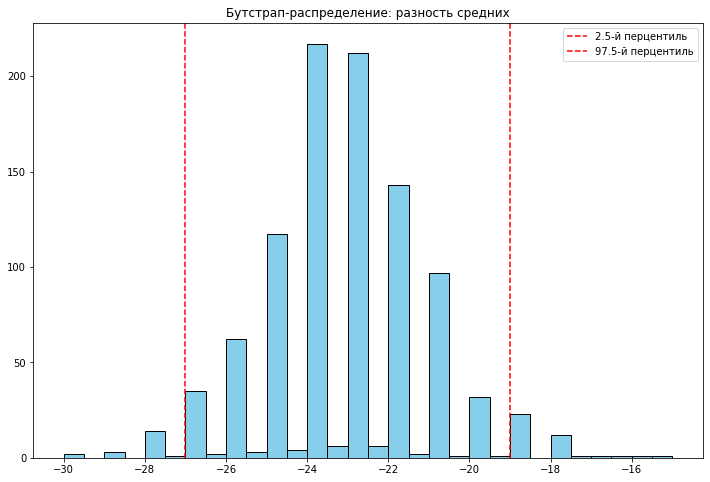

In [51]:
# Фиксируем сид для воспроизводимости
np.random.seed(341)
#Фильтруем платящих пользователей
pay_users = df_abt[df_abt['amount'] > 0]

control = pay_users[pay_users['group'] == 'control']
test = pay_users[pay_users['group'] == 'test']

control_group = control.groupby('user_id')['amount'].sum()
test_group = test.groupby('user_id')['amount'].sum()

n_iterations = 1000
boot_diffs = []

# Бутстрап-разница 50-х перцентилей между тестовой и контрольной группами
for i in range(n_iterations):
    boot_control = np.random.choice(control_group, size=len(control_group), replace=True)
    boot_test = np.random.choice(test_group, size=len(test_group), replace=True)

    # Для расчёта 50 перцентиля используем .percentile() из библиотеки numpy 
    control_50p = np.percentile(boot_control, 50)
    test_50p = np.percentile(boot_test, 50)

    # Находим разницу между значениями тестовой и контрольной групп
    boot_diffs.append(test_50p - control_50p)

# Создаём массив разниц между 50-ми перцентилями тестовой и контрольной групп
boot_diffs = np.array(boot_diffs)

# Доверительный интервал разницы между 50-ми перцентилями (перцентильный метод)
diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Вывод доверительного интервала
print(f"50-й перцентиль контрольной группы: {np.percentile(control_group, 50):.2f}")
print(f"50-й перцентиль тестовой группы: {np.percentile(test_group, 50):.2f}")
print(f"95%-й доверительный интервал разности 50-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]")

plt.figure(figsize=(12, 8))

# Визуализация
plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
plt.axvline(diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
plt.title("Бутстрап-распределение: разность средних")
plt.legend()
plt.show()

Результаты показывают статистически и практически значимое снижение сумм депозитов в тестовой группе:
- медиана снизилась на 24 руб. (с 118 до 94 руб.);
- 95 % доверительный интервал [−27,00;−19,00] подтверждает значимость эффекта;
- снижение составляет 20 % от исходного уровня.

Вывод: изменение оказало отрицательное влияние на суммы депозитов.

Сравним разницы 25-х перцентилей:

25-й перцентиль контрольной группы: 95.00
25-й перцентиль тестовой группы: 48.00
95%-й доверительный интервал разности 25-х перцентилей [-50.00, -44.00]


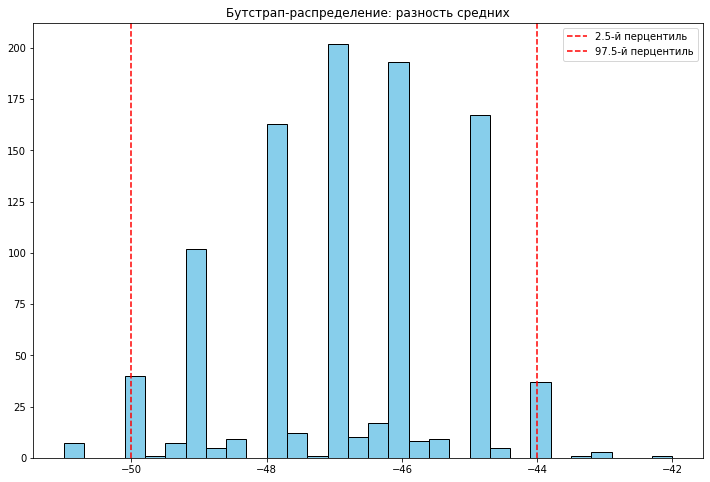

In [52]:
# Фиксируем сид для воспроизводимости
np.random.seed(341)
#Фильтруем платящих пользователей
pay_users = df_abt[df_abt['amount'] > 0]

control = pay_users[pay_users['group'] == 'control']
test = pay_users[pay_users['group'] == 'test']

control_group = control.groupby('user_id')['amount'].sum()
test_group = test.groupby('user_id')['amount'].sum()

n_iterations = 1000
boot_diffs = []

# Бутстрап-разница 25-х перцентилей между тестовой и контрольной группами
for i in range(n_iterations):
    boot_control = np.random.choice(control_amounts, size=len(control_group), replace=True)
    boot_test = np.random.choice(test_amounts, size=len(test_group), replace=True)

    # Для расчёта 25 перцентиля используем .percentile() из библиотеки numpy 
    control_25p = np.percentile(boot_control, 25)
    test_25p = np.percentile(boot_test, 25)

    # Находим разницу между значениями тестовой и контрольной групп
    boot_diffs.append(test_25p - control_25p)

# Создаём массив разниц между 25-ми перцентилями тестовой и контрольной групп
boot_diffs = np.array(boot_diffs)

# Доверительный интервал разницы между 25-ми перцентилями (перцентильный метод)
diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

# Вывод доверительного интервала
print(f"25-й перцентиль контрольной группы: {np.percentile(control_group, 25):.2f}")
print(f"25-й перцентиль тестовой группы: {np.percentile(test_group, 25):.2f}")
print(f"95%-й доверительный интервал разности 25-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]")

plt.figure(figsize=(12, 8))

# Визуализация
plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
plt.axvline(diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
plt.title("Бутстрап-распределение: разность средних")
plt.legend()
plt.show()

Результаты показывают статистически и практически значимое снижение сумм депозитов в нижнем сегменте (25‑й перцентиль) в тестовой группе:
- 25‑й перцентиль снизился на 47 руб. (с 95 до 48 руб.);
- 95 % доверительный интервал [−58,00;−53,99] подтверждает значимость эффекта;
- снижение составляет 49 % от исходного уровня.

Вывод: изменение оказало выраженное отрицательное влияние на суммы минимальных депозитов.

Наиболее сильное негативное воздействие новая фича оказала на пользователей, вносящих небольшие суммы:
- снижение 25‑го перцентиля на 49 % — критически значимый эффект;
- пользователи нижнего сегмента стали либо вносить существенно меньшие суммы, либо вовсе отказываться от депозитов;

Эффект распространяется и на основную массу пользователей:
- медиана снизилась на 20 %;
- это говорит о том, что изменение затронуло не только крайние сегменты, но и «типичного» пользователя;
- средний сегмент тоже реагирует негативно, но менее резко, чем мелкие инвесторы.

В сегменте крупных депозитов:
- рост на 12,9 % (179,50/159,00≈1,129).
- абсолютный прирост: +20,50.
- крупные инвесторы активнее вовлекаются в продукт.

---

### 5. Выводы



Гипотеза частично подтвердилась:

Ключевая метрика (средняя сумма всех депозитов на пользователя) выросла на 2,46 % (92,46 против 90,24) — разница статистически не значима.

Вспомогательные метрики показали значительный рост:
- конверсия из первого депозита во второй выросла на 60,95 % (32,61 % против 19,98 %) — статистически значимо;
- средняя сумма депозитов у платящих пользователей выросла на 4,35 % (141,4 против 135,50) — статистически значимо.

Ожидание роста вспомогательных метрик выполнено с превышением.

Но барьерная метрика ухудшилась: конверсия из регистрации в первый депозит снизилась на 2,11 % (70,04 % против 71,54 %) — но разница не статистически значима.

Положительные эффекты:

- Значительный рост конверсии во второй депозит (+60,95 %).
- Рост средней суммы депозитов как среди всех пользователей (+2,72 %), так и среди платящих (+4,62 %).
- Улучшение показателей на поздних этапах воронки:
  - покупка актива: +6,7 п.п. (43,3 % против 36,6 %);
  - второй депозит: +7,8 п.п. (21,3 % против 13,5 %) в классической воронке;
  - в step‑by‑step воронке рост ещё более выраженный: второй депозит +12,4 п.п. (49,3 % против 36,9 %).
- Рост 75‑го перцентиля (+20,50):
  - 75‑й перцентиль тестовой группы — 179,50, контрольной — 159,00;
  - крупные инвесторы активнее вовлекаются и увеличивают вложения.

Отрицательные эффекты:

- Снижение конверсии на этапе онбординга:
  - классическая воронка: −8 п.п. (75,8 % против 83,8 %);
  - step‑by‑step воронка: −9,3 п.п. (88,3 % против 97,6 %).

- Падение перцентилей суммы депозитов для платящих пользователей:
  - 25‑й перцентиль: −49 % (48,00 против 95,00) — значимо;
  - 50‑й перцентиль: −20 % (94,00 против 118,00) — значимо;

- Поляризация аудитории:
  - разрыв между крупными и мелкими инвесторами увеличивается;
  - выручка всё больше зависит от верхних 25 % пользователей.
  
Инсайты:
- снижение конверсии на этапе onboarding_complete требует доработки интерфейса и UX на ранних этапах взаимодействия. Возможно новый онбординг слишком сложный и поэтому пользователи уходят, не закончив его просмотр. Либо информация о степени рисков активов отпугивает часть пользователей.
- падение 25‑го и 50‑го перцентилей указывает на проблемы у пользователей с небольшими вложениями — нужно изучить их поведение и мотивацию.

Таким образом новый онбординг имеет выраженные плюсы (рост конверсии во второй депозит, увеличение средней суммы депозитов) и явные минусы (ухудшение онбординга, падение сумм депозитов у части пользователей).

Рекомендация: Новый онбординг повышает вовлечённость и удержание пользователей, особенно крупных инвесторов и тех, кто готов к риску. Однако он рискует оттолкнуть осторожных новичков и мелких инвесторов, что может привести к долгосрочному падению выручки.Можно запускать фичу для части пользователей с постепенной раскаткой и планом доработки. Необходимо доработать фичу для категории пользователей с низкими и средними суммами депозитов.